# Lab 1: Arithmetic Intensity Visualization Lab

By completing this assignment, you will:
1. Understand the concept of **arithmetic intensity** and its impact on GPU performance
2. Learn how to measure GPU compute performance (TFLOPS)
3. Benchmark matrix operations and analyze the transition from memory-bounded to compute-bounded operations
4. Create visualizations to analyze GPU utilization using the Roofline model

## Instructions for Grading
1. Complete **Task 1** and **Task 2** (the only TODO sections)
2. Run all cells to generate the `answers.yaml` file
3. Submit the `answers.yaml` file for grading

## Grading (30 points)
1. TFLOPS Calculation — *required but not graded*
2. Arithmetic Intensity Calculation — **30 points**
3. Visualization — *provided (no implementation needed)*

## Environment Setup

runtime base container: `nvcr.io/nvidia/nemo-automodel:25.11`

In [1]:
!pip install pandas plotly nbformat pyyaml -q

In [2]:
# plot visualization
import plotly.io as pio

pio.renderers.default = "colab"  # classic Jupyter Notebook

In [3]:
!pip install numpy torch

In [4]:
from typing import Dict, List

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
import yaml
from plotly.subplots import make_subplots

In [19]:
import matplotlib.pyplot as plt

## Background

**Arithmetic Intensity (AI)** = FLOPs / Bytes Accessed

For matrix multiplication `C = A @ B` where A and B are N×N matrices:

## Task 1: Implement TFLOPS Calculation (15 points)

**Formula**:
- FLOPs for N×N matmul: `2 * N³`
- Each element of C requires N multiplications and N−1 additions.
- TFLOPS (Tera FLOPs per Second) = `(FLOPs / time_seconds) / 1e12`

In [5]:
def calculate_tflops(matrix_size: int, time_seconds: float) -> float:
    """
    Calculate achieved TFLOPS for matrix multiplication C = X @ X.

    Args:
        matrix_size: Size of square matrix (N x N)
        time_seconds: Execution time in seconds

    Returns:
        Achieved TFLOPS (Tera FLOPs per second)
    """
    return ((2 * (matrix_size ** 3)) / time_seconds) / 1e12

## Task 2: Implement Arithmetic Intensity Calculation (15 points)

**Formula**:
- Bytes = `3 * N² * bytes_per_element` (2 bytes for FP16, 4 bytes for FP32)
- AI = `FLOPs / Bytes`

In [6]:
def calculate_arithmetic_intensity(matrix_size: int, dtype: torch.dtype) -> float:
    """
    Calculate arithmetic intensity (FLOPs per Byte) for matrix multiplication.

    Args:
        matrix_size: Size of square matrix (N x N)
        dtype: Data type of matrix

    Returns:
        Arithmetic intensity (FLOPs/Byte)
    """
    flops = 2 * (matrix_size ** 3)
    bytes_transfer = 3 * (matrix_size ** 2) * (2 if dtype == torch.float16 else 4)
    return flops/bytes_transfer

In [7]:
# Provided: Benchmark function
def benchmark_matmul(
    size: int,
    dtype: torch.dtype,
    device: torch.device,
    num_warmup: int = 10,
    num_iterations: int = 100,
) -> Dict:
    """Benchmark matrix multiplication C = X @ X for a given size."""
    X = torch.randn(size, size, dtype=dtype, device=device)

    # Warmup
    for _ in range(num_warmup):
        _ = torch.matmul(X, X)

    torch.cuda.synchronize()
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    for _ in range(num_iterations):
        result = torch.matmul(X, X)
    end_event.record()
    torch.cuda.synchronize()

    elapsed_time_ms = start_event.elapsed_time(end_event)
    avg_time_ms = elapsed_time_ms / num_iterations
    avg_time_s = avg_time_ms / 1000.0

    achieved_tflops = calculate_tflops(size, avg_time_s)
    arithmetic_intensity = calculate_arithmetic_intensity(size, dtype)

    return {
        "size": size,
        "time_ms": avg_time_ms,
        "achieved_tflops": achieved_tflops,
        "arithmetic_intensity": arithmetic_intensity,
    }

In [8]:
# Provided: Run benchmarks
def run_benchmarks(sizes: List[int], dtype: torch.dtype = torch.float16) -> pd.DataFrame:
    """Run benchmarks for multiple matrix sizes."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available!")

    device = torch.device("cuda:0")
    props = torch.cuda.get_device_properties(device)
    print(f"GPU: {props.name}")
    print(f"Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"\nRunning benchmarks with dtype={dtype}")
    print("-" * 60)
    print(f"{'Size':>8} {'Time(ms)':>12} {'TFLOPS':>10} {'AI':>12}")
    print("-" * 60)

    results = []
    for size in sizes:
        result = benchmark_matmul(size, dtype, device)
        results.append(result)
        print(f"{result['size']:8d} {result['time_ms']:12.4f} "
              f"{result['achieved_tflops']:10.2f} "
              f"{result['arithmetic_intensity']:12.2f}")
    print("-" * 60)
    return pd.DataFrame(results)

In [22]:
def plot_results_mpl(df, peak_tflops, peak_bandwidth_gbps):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    sizes = df.index.values

    # Plot 1: AI vs Size
    axes[0, 0].plot(sizes, df["arithmetic_intensity"], 'o-', color='blue')
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_title("Arithmetic Intensity vs Matrix Size")
    axes[0, 0].set_ylabel("FLOPs/Byte")

    # Plot 2: TFLOPS vs Size
    axes[0, 1].plot(sizes, df["achieved_tflops"], 'o-', color='green')
    axes[0, 1].axhline(y=peak_tflops, color='red', linestyle='--', label=f'Peak {peak_tflops}')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_title("Achieved TFLOPS vs Matrix Size")
    axes[0, 1].legend()

    # Plot 3: Time vs Size
    axes[1, 0].plot(sizes, df["time_ms"], 'o-', color='red')
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title("Execution Time vs Matrix Size")
    axes[1, 0].set_ylabel("Time (ms)")

    # Plot 4: Roofline Model
    # Calculate Roofline boundary
    ai_range = np.logspace(np.log10(df["arithmetic_intensity"].min() * 0.5),
                           np.log10(df["arithmetic_intensity"].max() * 2), 100)
    mem_bound = (peak_bandwidth_gbps / 1000) * ai_range
    roofline = np.minimum(mem_bound, peak_tflops)

    axes[1, 1].plot(ai_range, roofline, '--', color='red', label='Roofline')
    scatter = axes[1, 1].scatter(df["arithmetic_intensity"], df["achieved_tflops"],
                                 c=np.log10(sizes), cmap='viridis', s=100, zorder=5)
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title("Roofline Model")
    axes[1, 1].set_xlabel("Arithmetic Intensity (FLOPs/Byte)")
    axes[1, 1].set_ylabel("Performance (TFLOPS)")

    plt.colorbar(scatter, ax=axes[1, 1], label='Matrix Size (log10)')
    plt.show()

---
## Run Benchmarks & Visualization

In [10]:
# Matrix sizes and run benchmarks
sizes = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

df_fp16 = run_benchmarks(sizes, torch.float16).set_index("size")
df_fp32 = run_benchmarks(sizes, torch.float32).set_index("size")

df_fp16

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Total Memory: 101.97 GB

Running benchmarks with dtype=torch.float16
------------------------------------------------------------
    Size     Time(ms)     TFLOPS           AI
------------------------------------------------------------
      16       0.0055       0.00         5.33
      32       0.0055       0.01        10.67
      64       0.0055       0.09        21.33
     128       0.0055       0.77        42.67
     256       0.0055       6.13        85.33
     512       0.0062      43.14       170.67
    1024       0.0123     173.95       341.33
    2048       0.0675     254.44       682.67
    4096       0.4687     293.24      1365.33
    8192       3.5691     308.07      2730.67
   16384      28.6704     306.80      5461.33
------------------------------------------------------------
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Total Memory: 101.97 GB

Running benchmarks with dtype=torch.float32
---------------------------

,time_ms,achieved_tflops,arithmetic_intensity
size,,,
16,0.005544,0.001478,5.333333
32,0.005490,0.011938,10.666667
64,0.005539,0.094650,21.333333
128,0.005477,0.765786,42.666667
256,0.005474,6.129514,85.333333
512,0.006223,43.137961,170.666667
1024,0.012346,173.947287,341.333333
2048,0.067519,254.443604,682.666667
4096,0.468686,293.243288,1365.333333


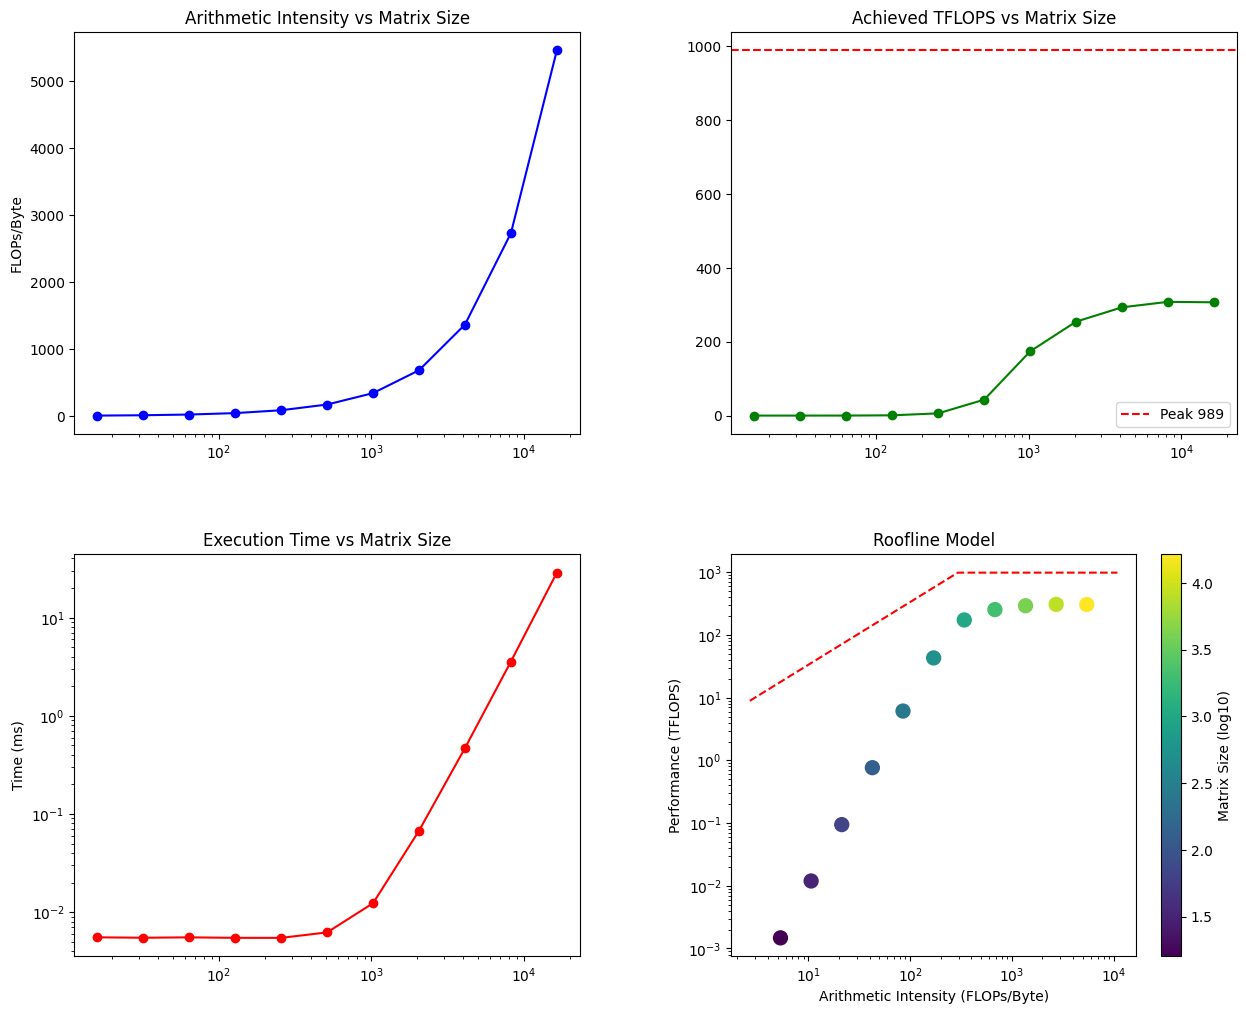

In [24]:
# Visualization (H100 specs)
peak_tflops = 989
peak_bandwidth_gbps = 3350

# Call the function
plot_results_mpl(df_fp16, peak_tflops, peak_bandwidth_gbps)

---
## Generate answers.yaml for Submission

In [12]:
# Generate answers for grading - extract directly from benchmark DataFrames
answers = {}

for n in [16, 64, 256, 1024, 4096]:
    answers[f"ai_fp16_n{n}"] = float(df_fp16.loc[n, "arithmetic_intensity"])
    answers[f"ai_fp32_n{n}"] = float(df_fp32.loc[n, "arithmetic_intensity"])

!mkdir -p submission
# Save
with open("submission/answers.yaml", "w") as f:
    yaml.dump(answers, f, default_flow_style=False, sort_keys=True)

print("✅ answers.yaml generated!")
print(yaml.dump(answers, default_flow_style=False, sort_keys=True))

✅ answers.yaml generated!
ai_fp16_n1024: 341.3333333333333
ai_fp16_n16: 5.333333333333333
ai_fp16_n256: 85.33333333333333
ai_fp16_n4096: 1365.3333333333333
ai_fp16_n64: 21.333333333333332
ai_fp32_n1024: 170.66666666666666
ai_fp32_n16: 2.6666666666666665
ai_fp32_n256: 42.666666666666664
ai_fp32_n4096: 682.6666666666666
ai_fp32_n64: 10.666666666666666



## Submission

Submit `submission` for grading. Grade with:
```bash
python grade_assignment.py submission
```